In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

In [2]:
!pip install pandas numpy matplotlib pmdarima statsmodels prophet scikit-learn

In [3]:
!pip install prophet

In [4]:
df=pd.read_csv(r"C:\Users\ghazi\Desktop\Predictive Analytics Forecasting\Sales Analysis Report.csv")

In [5]:
df.columns = df.columns.str.lower()

In [6]:
df=df.rename(columns={'item type':'category'})

In [7]:
df['order date'] = pd.to_datetime(df['order date'])

In [8]:
df = df.sort_values('order date')
df= df.set_index('order date')
sales = df['total revenue'].resample('M').sum()

C:\Users\ghazi\AppData\Local\Temp\ipykernel_9536\3981478045.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales = df['total revenue'].resample('M').sum()


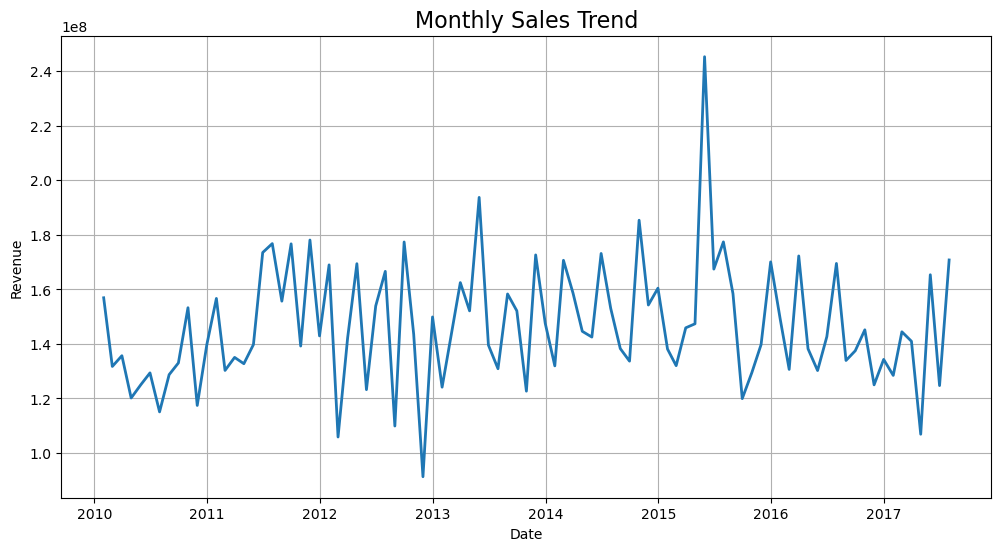

In [18]:
plt.figure(figsize=(12,6))
plt.plot(sales, linewidth=2)
plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [10]:
train = sales[:-12]
test = sales[-12:]

In [11]:
arima_model = auto_arima(train, seasonal=False, trace=True)
forecast_arima = arima_model.predict(n_periods=12)
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
print("ARIMA RMSE:", rmse_arima)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2919.981, Time=0.47 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3200.245, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2959.415, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=3152.261, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=2919.935, Time=0.15 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=3145.288, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2915.899, Time=0.16 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2917.868, Time=0.28 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=2908.928, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=2907.084, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=2905.183, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=2907.049, Time=0.04 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0] intercept
Total fit time: 1.586 seconds
ARIMA RMSE: 19321002.984779

In [12]:
sarima_model = SARIMAX(train,
                       order=arima_model.order,
                       seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit()
forecast_sarima = sarima_fit.forecast(12)
rmse_sarima = np.sqrt(mean_squared_error(test, forecast_sarima))
print("SARIMA RMSE:", rmse_sarima)

SARIMA RMSE: 22567205.408292145


In [13]:
prophet_data = sales.reset_index()
prophet_data.columns = ['ds','y']
model = Prophet()
model.fit(prophet_data)
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)
prophet_forecast = forecast['yhat'][-12:]
rmse_prophet = np.sqrt(mean_squared_error(test, prophet_forecast))
print("Prophet RMSE:", rmse_prophet)

15:58:49 - cmdstanpy - INFO - Chain [1] start processing
15:58:50 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\ghazi\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


Prophet RMSE: 15698388.402361995


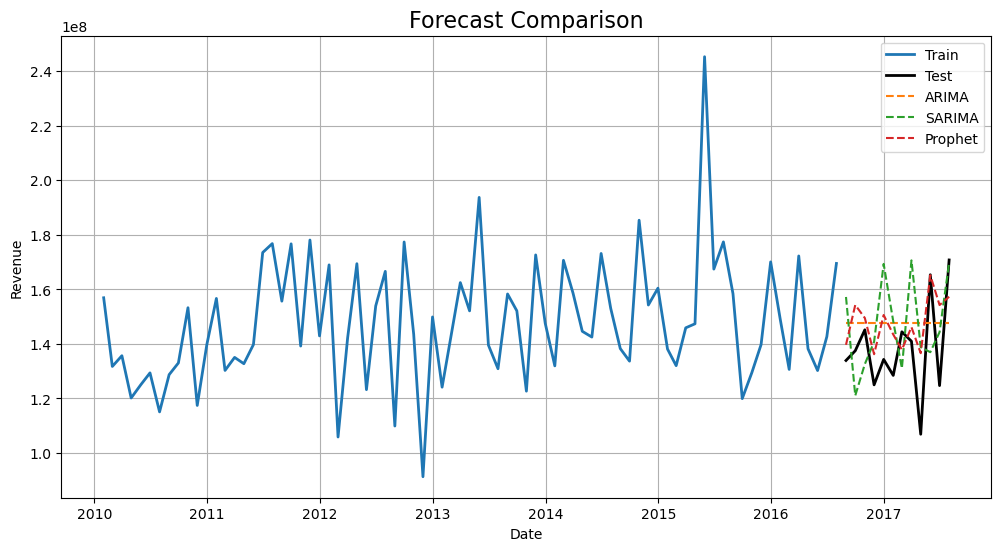

In [19]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train', linewidth=2)
plt.plot(test.index, test, label='Test', linewidth=2, color='black')

plt.plot(test.index, forecast_arima, label='ARIMA', linestyle='--')
plt.plot(test.index, forecast_sarima, label='SARIMA', linestyle='--')
plt.plot(test.index, prophet_forecast, label='Prophet', linestyle='--')

plt.legend()
plt.title("Forecast Comparison", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [16]:
sales_trend = df.groupby('order date')['total revenue'].sum().reset_index()

16:00:45 - cmdstanpy - INFO - Chain [1] start processing
16:00:45 - cmdstanpy - INFO - Chain [1] done processing


<Figure size 1000x600 with 0 Axes>

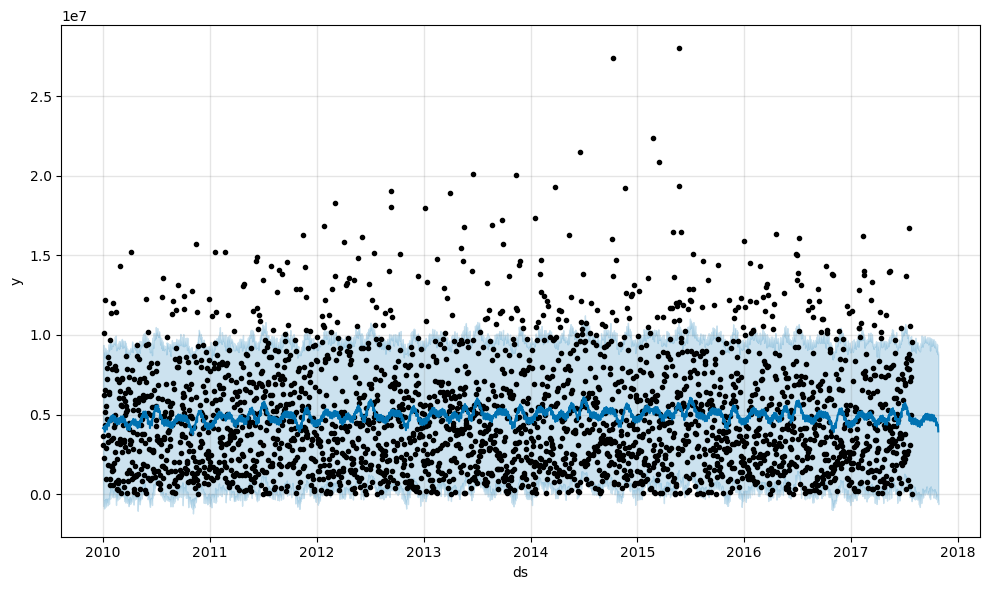

<Figure size 1000x600 with 0 Axes>

In [17]:
forecast_df = sales_trend.rename(columns={'order date':'ds','total revenue':'y'})
model = Prophet()
model.fit(forecast_df)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)
model.plot(forecast)
plt.figure(figsize=(10,6))